In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

from utils import load_excel_sheets, process_benchmark_stats, aggregate_stats, global_model_list

# Unpacking

In [3]:
dfs = load_excel_sheets('../data/PB1/P2/WMS','../data/PB1/P2/MS','../data/PB1/P1B')

print("\nLoaded dataframe keys:", list(dfs.keys()))

 Loaded: ChatGPT-o1_WMS.xlsx Sheets:[3/3]
 Loaded: Human_ms.xlsx Sheets:[3/3]
 Loaded: DeepSeek-V3_WMS.xlsx Sheets:[3/3]
 Loaded: ChatGPT-4o_WMS.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o3_WMS.xlsx Sheets:[3/3]
 Loaded: Gemini 1.5_WMS.xlsx Sheets:[3/3]
 Loaded: Gemini 2.0_WMS.xlsx Sheets:[3/3]
 Loaded: DeepSeek-V3_MS.xlsx Sheets:[3/3]
 Loaded: Human_ms.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o1_MS.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o3_MS.xlsx Sheets:[3/3]
 Loaded: ChatGPT-4o_MS.xlsx Sheets:[3/3]
 Loaded: Gemini 2.0_MS.xlsx Sheets:[3/3]
 Loaded: Gemini 1.5_MS.xlsx Sheets:[3/3]
 Loaded: Gemini 2.0_t.xlsx Sheets:[3/3]
 Loaded: DeepSeek-V3_t.xlsx Sheets:[3/3]
 Loaded: ChatGPT-4o_t.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o1_t.xlsx Sheets:[3/3]
 Loaded: Gemini 1.5_t.xlsx Sheets:[3/3]
 Loaded: ChatGPT-o3_t.xlsx Sheets:[3/3]

Loaded dataframe keys: ['WMS_ChatGPT-o1_CM', 'WMS_ChatGPT-o1_EM', 'WMS_ChatGPT-o1_QM', 'WMS_Human_CM', 'WMS_Human_EM', 'WMS_Human_QM', 'WMS_DeepSeek-V3_CM', 'WMS_DeepSeek-V3_EM', 'WMS_De

In [4]:
process_benchmark_stats(dfs)
# Verify the result with the first dataframe
if dfs:
    first_key = list(dfs.keys())[0]
    print(f"\nFirst 5 rows of {first_key}:")
    display(dfs[first_key].head())

Processing DataFrames: 100%|██████████| 60/60 [00:00<00:00, 961.71it/s]


First 5 rows of WMS_ChatGPT-o1_CM:


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
0,1,6,6,6,6,WMS,ChatGPT-o1,CM,WMS_ChatGPT-o1_CM,6.000000,0.000000,100.000000,0.000000
1,2,9,9,9,5,WMS,ChatGPT-o1,CM,WMS_ChatGPT-o1_CM,7.666667,2.309401,85.185185,25.660012
2,3,13,13,13,11,WMS,ChatGPT-o1,CM,WMS_ChatGPT-o1_CM,12.333333,1.154701,94.871795,8.882312
3,4,10,10,10,10,WMS,ChatGPT-o1,CM,WMS_ChatGPT-o1_CM,10.000000,0.000000,100.000000,0.000000
4,5,7,7,7,7,WMS,ChatGPT-o1,CM,WMS_ChatGPT-o1_CM,7.000000,0.000000,100.000000,0.000000


In [5]:
# Create master df and summary df for plotting
master_df, summary_stats = aggregate_stats(dfs)

display(master_df.head())
display(summary_stats.head())

/Users/jonah/Github - Projects/LLM Project paper/AI-in-Physics-in-Education-j/Plot code/utils.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_stats = master_df.groupby(['Dir', 'Model', 'Sheet']).agg(


,Question Number,Available Marks,Solution 1,Solution 2,Solution 3,Dir,Model,Sheet,key,mean solution,std solution,mean percentage mark,std percentage
198,1,6,6.0,6.0,6.0,MS,ChatGPT-4o,CM,MS_ChatGPT-4o_CM,6.000000,0.000000,100.000000,0.000000
199,2,9,9.0,9.0,6.5,MS,ChatGPT-4o,CM,MS_ChatGPT-4o_CM,8.166667,1.443376,90.740741,16.037507
200,3,13,13.0,13.0,12.5,MS,ChatGPT-4o,CM,MS_ChatGPT-4o_CM,12.833333,0.288675,98.717949,2.220578
201,4,10,10.0,10.0,9.5,MS,ChatGPT-4o,CM,MS_ChatGPT-4o_CM,9.833333,0.288675,98.333333,2.886751
202,5,7,7.0,7.0,7.0,MS,ChatGPT-4o,CM,MS_ChatGPT-4o_CM,7.000000,0.000000,100.000000,0.000000


,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,MS,ChatGPT-4o,CM,97.798742,3.614310,1.475536
1,MS,ChatGPT-4o,EM,95.918367,13.608276,5.555556
2,MS,ChatGPT-4o,QM,95.480226,5.551592,2.266428
3,MS,Gemini 1.5,CM,100.000000,0.000000,0.000000
4,MS,Gemini 1.5,EM,95.238095,9.366783,3.823973


In [6]:
# Useful variables for plotting
unique_models = master_df['Model'].unique()
model_list = [model for model in global_model_list if model in unique_models]
topic_sheet_df = summary_stats.groupby(['Dir','Sheet'])

display(topic_sheet_df.get_group(('MS', 'CM')))

# Get unique dirs and sheets for plotting
dir_list = master_df['Dir'].unique()
sheet_list = master_df['Sheet'].unique()

print("Dirs:", dir_list)
print("Sheets:", sheet_list)

# Colors
colors = ["#1b75b5", '#ff7f0e', '#2ca02c', '#d62728', "#7b46ad", '#8c564b','#7f7f7f']

,Dir,Model,Sheet,Total_Mean%,Total_Std,Total_Std_error%
0,MS,ChatGPT-4o,CM,97.798742,3.614310,1.475536
3,MS,Gemini 1.5,CM,100.000000,0.000000,0.000000
6,MS,ChatGPT-o1,CM,95.597484,5.772179,2.356482
9,MS,Gemini 2.0,CM,96.855346,5.927855,2.420037
12,MS,DeepSeek-V3,CM,85.534591,8.842047,3.609751
15,MS,ChatGPT-o3,CM,85.534591,13.244284,5.406956
18,MS,Human,CM,83.018868,15.013610,6.129281


Dirs: ['MS' 'P1B' 'WMS']
Sheets: ['CM' 'EM' 'QM']


# Bar 1

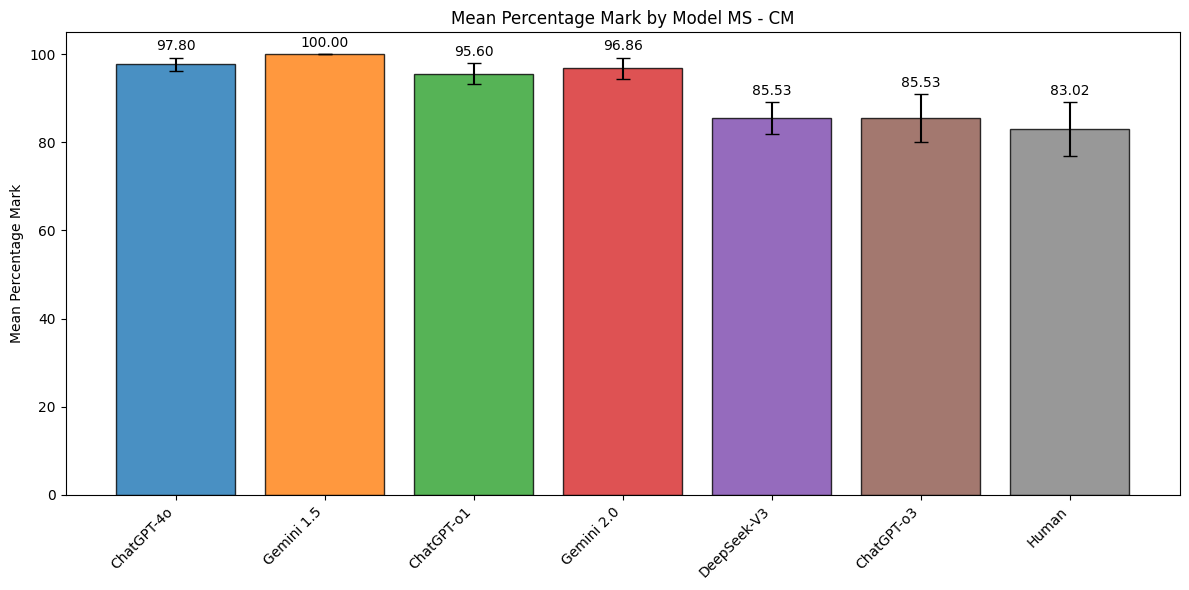

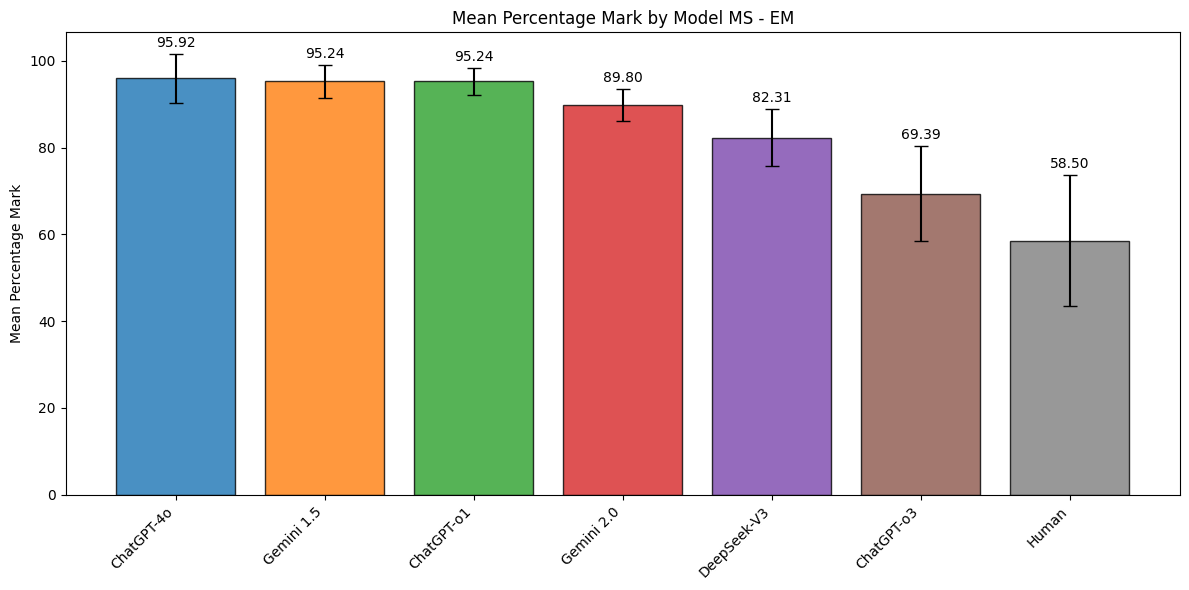

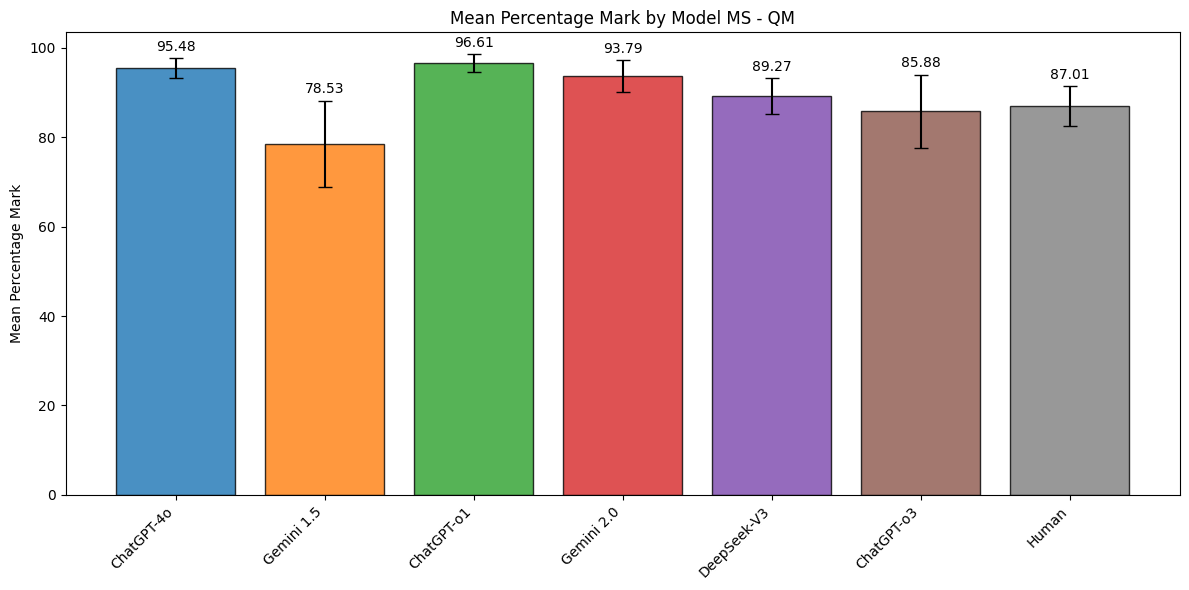

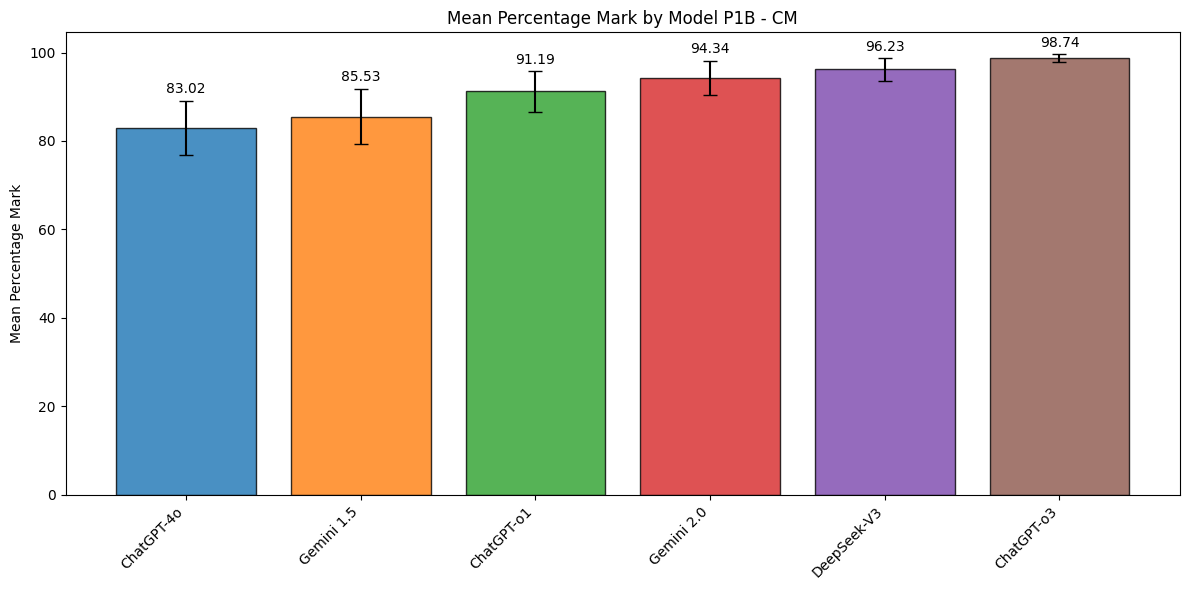

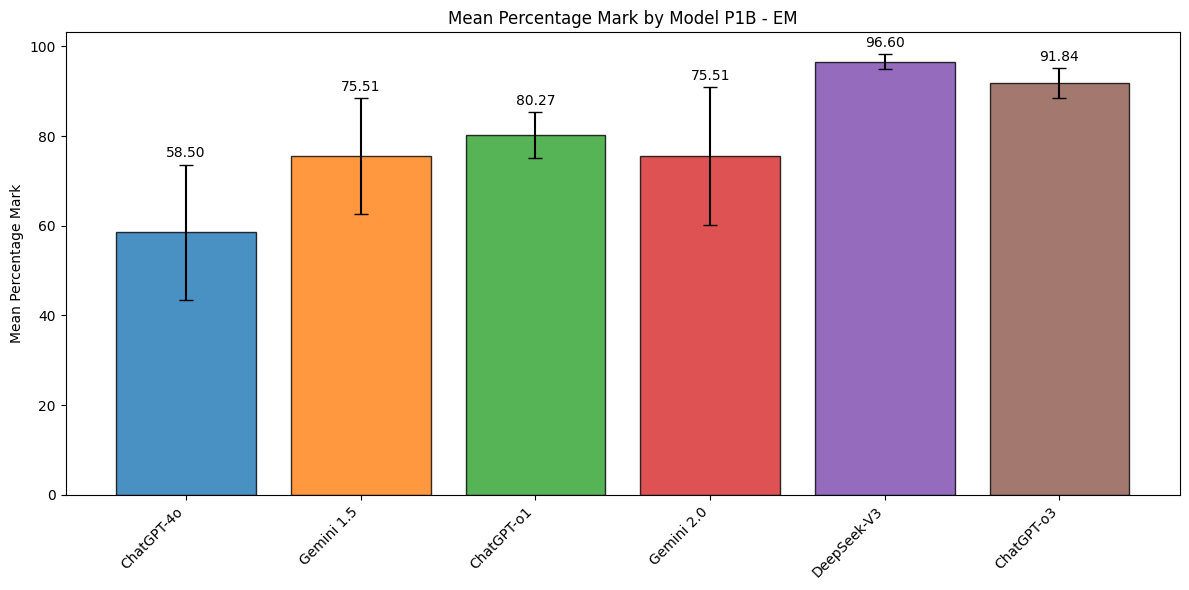

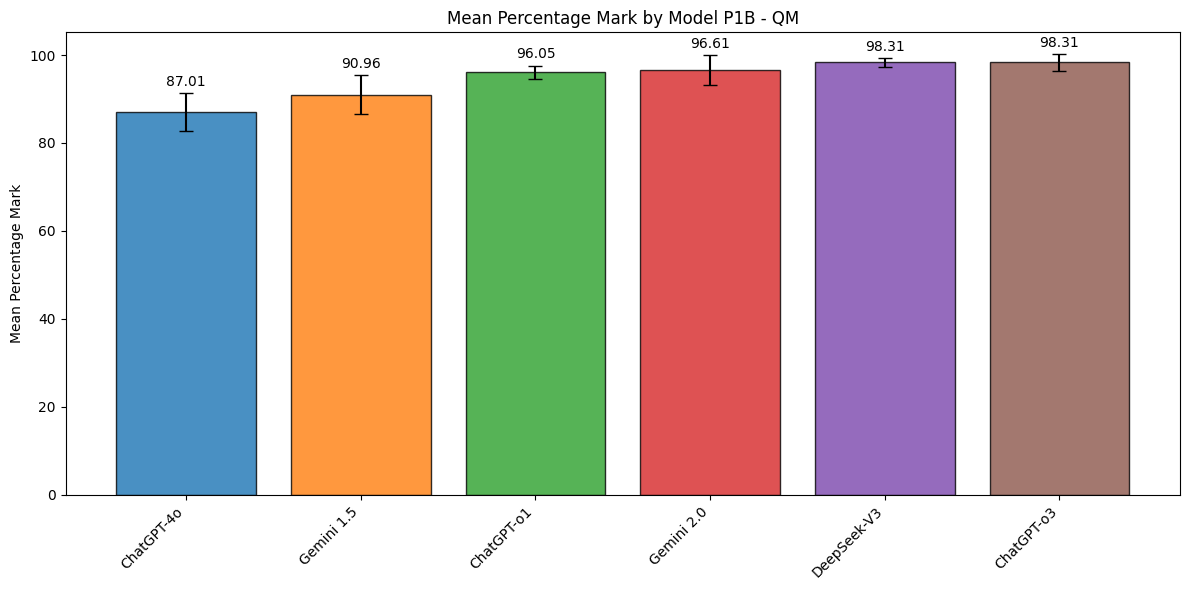

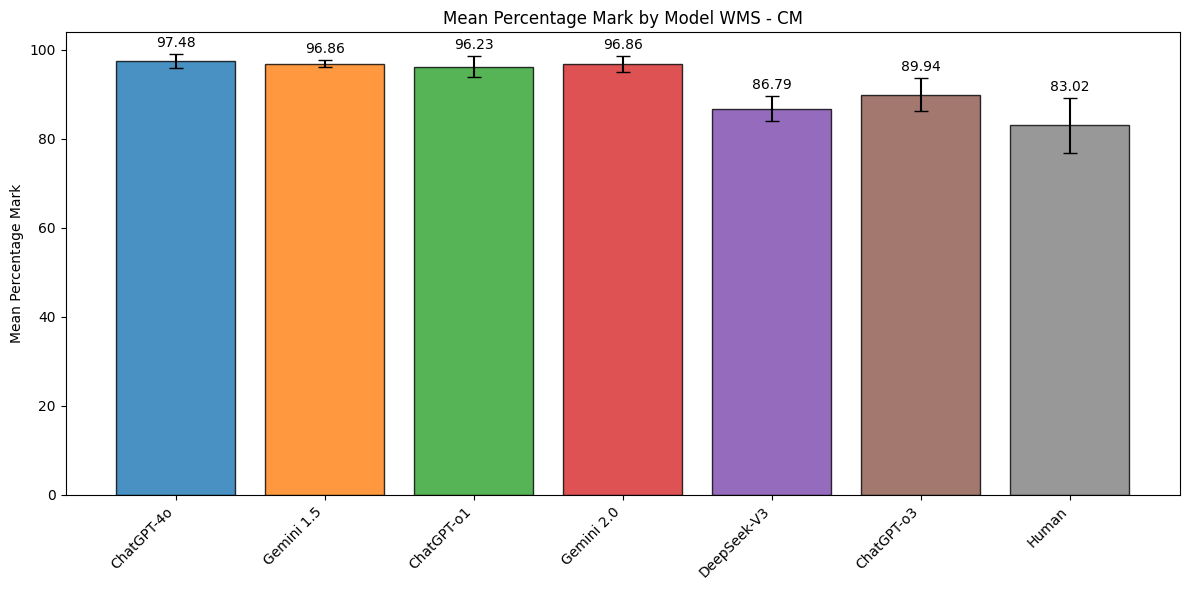

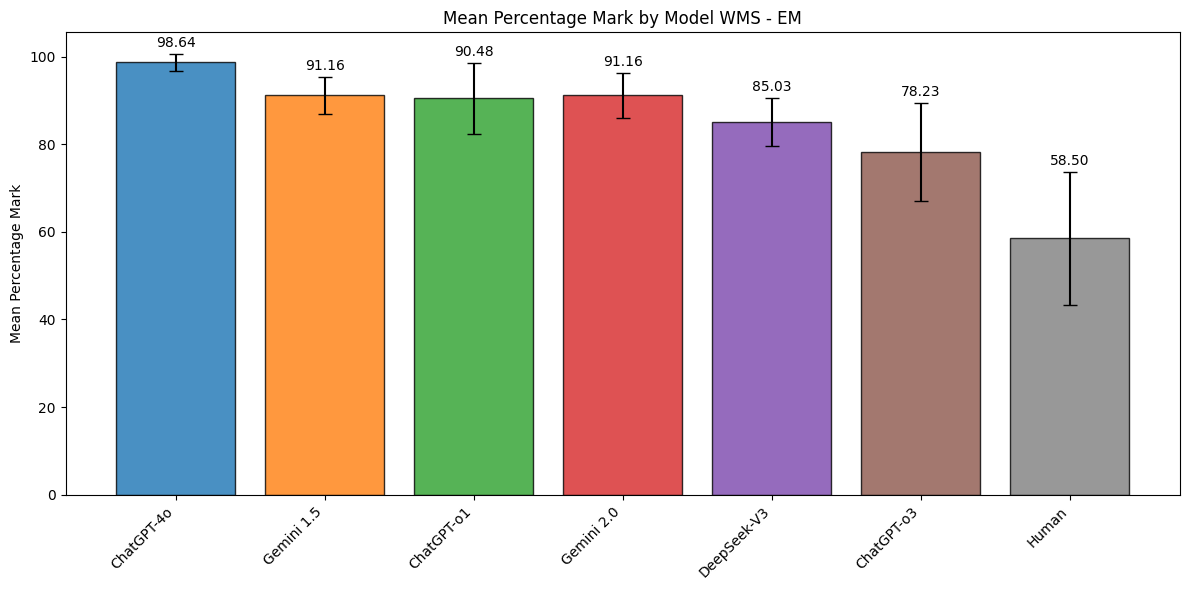

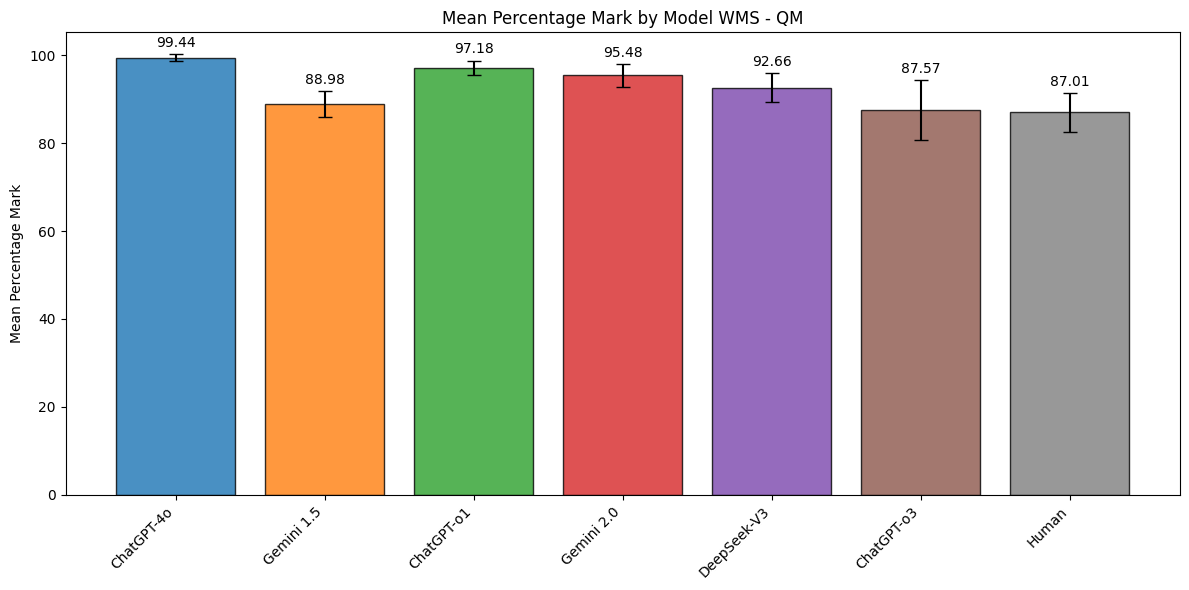

In [7]:
for dir in dir_list:
    for sheet in sheet_list:
        # Extract data
        try:
            group = topic_sheet_df.get_group((dir, sheet))
        except KeyError:
            continue # Skip completely if this Dir/Sheet combo doesn't exist
            
        group = group.dropna(subset=['Total_Mean%'])
        
        # If dropping the missing models leaves the group completely empty, skip plotting
        if group.empty:
            continue

        # 1. Grab the exact models and stats present in THIS specific group
        current_models = group['Model']
        means = group['Total_Mean%']
        std_errs = group['Total_Std_error%']

        fig, ax = plt.subplots(figsize=(12, 6))

        # 2. Set X to match the actual number of rows left in the group
        x = np.arange(len(current_models)) 
        
        # Plotting
        rects1 = ax.bar(x, means, width=0.8, yerr=std_errs, 
                        capsize=5, color=colors, edgecolor='black', alpha=0.8)

        ax.set_ylabel('Mean Percentage Mark')
        ax.set_title(f'Mean Percentage Mark by Model {dir} - {sheet}')
        ax.set_xticks(x)
        
        # 4. Use the current_models for the labels so they align perfectly
        ax.set_xticklabels(current_models, rotation=45, ha='right')

        # Add labels 
        ax.bar_label(rects1, padding=3, fmt='%.2f')

        plt.tight_layout()
        plt.show()

# Bar diffs

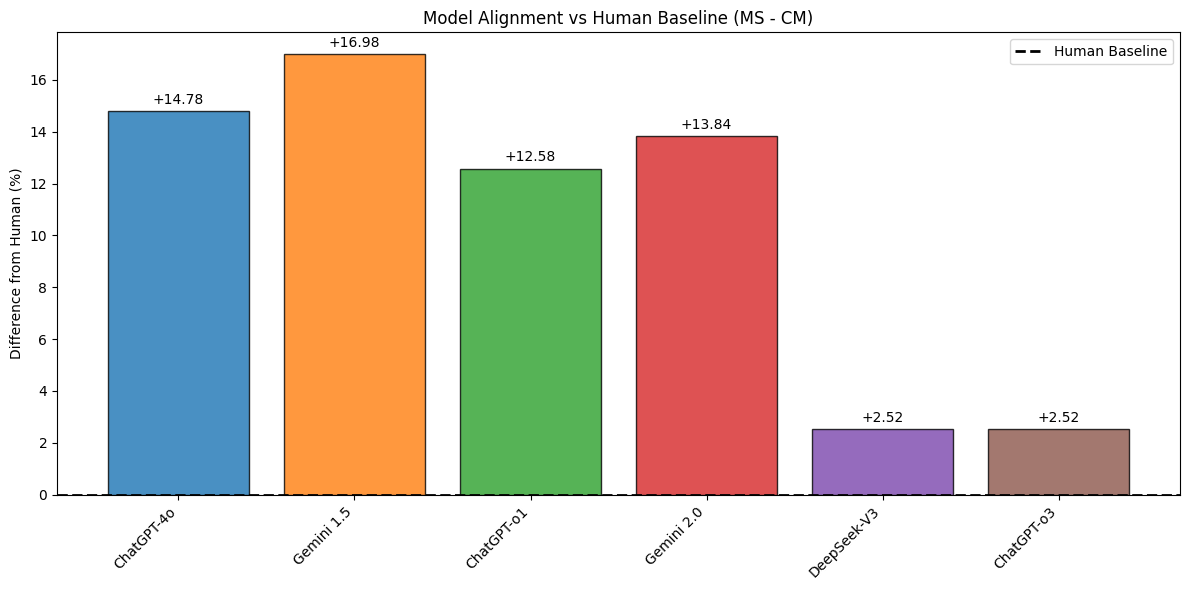

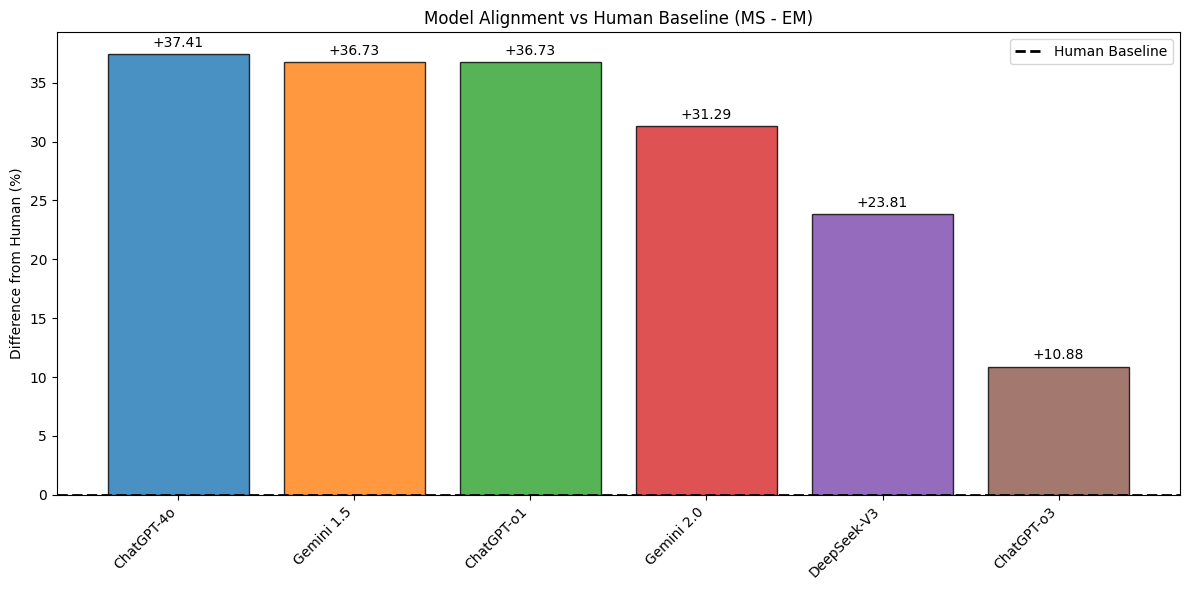

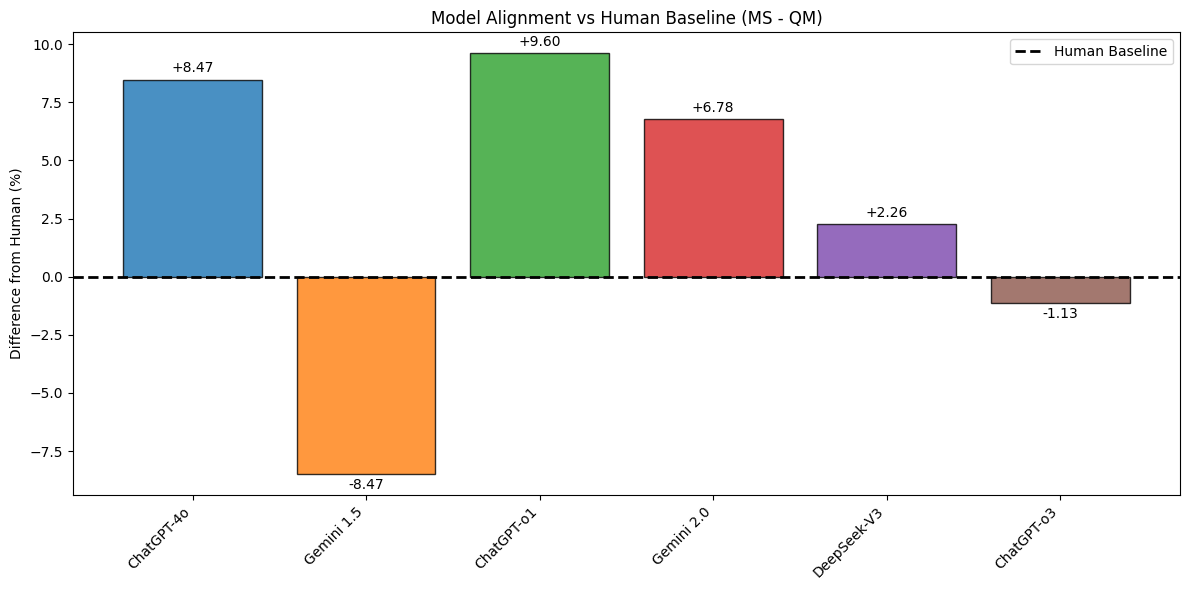

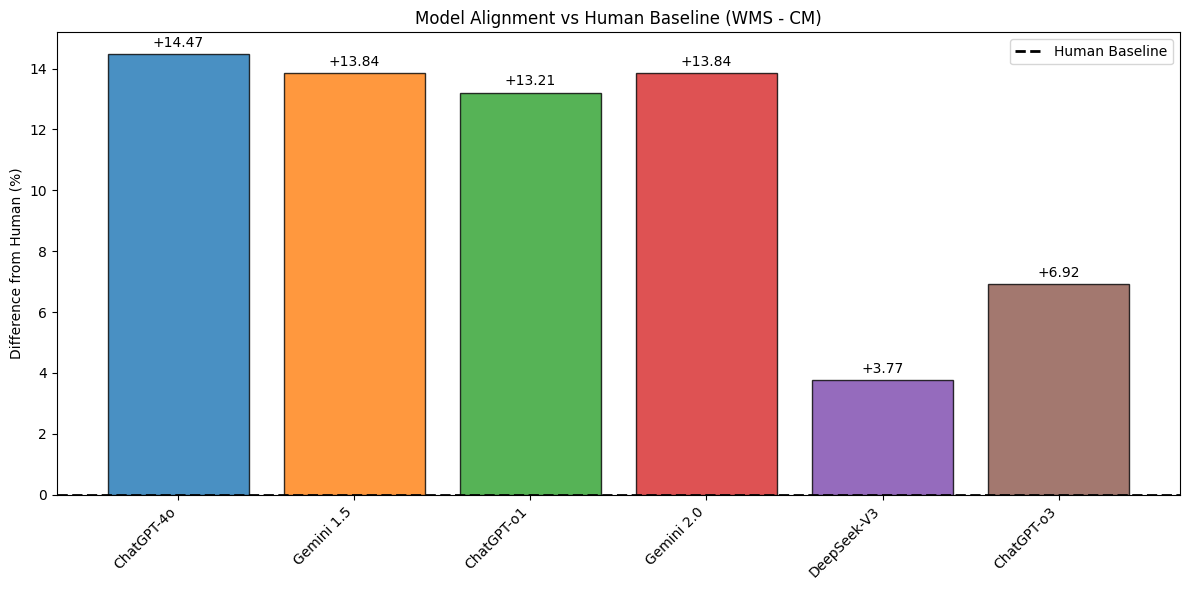

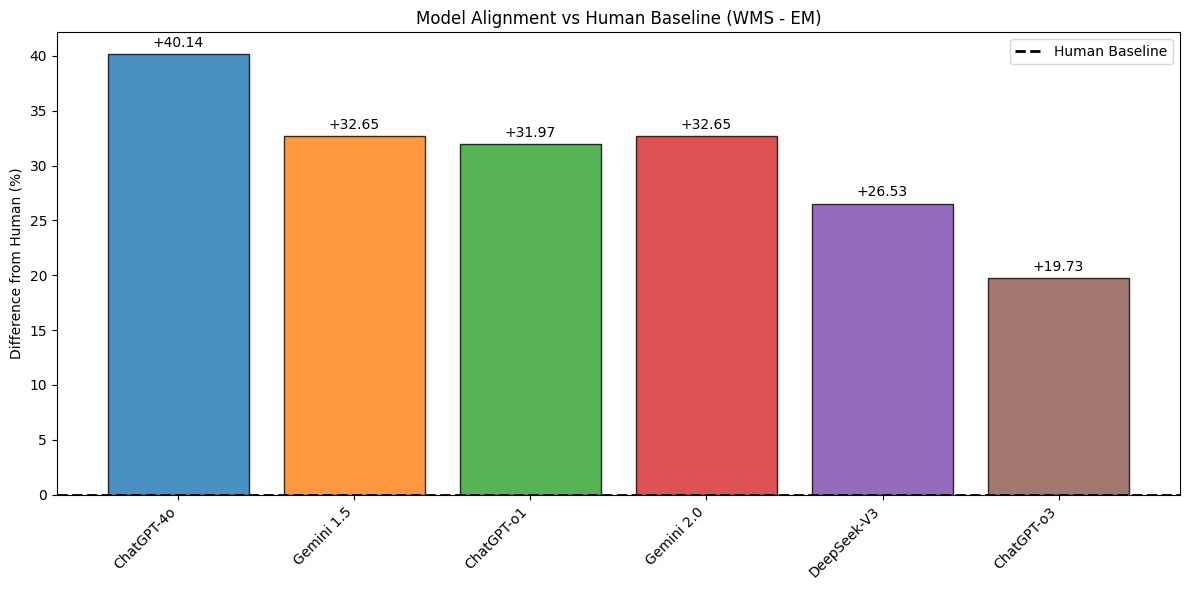

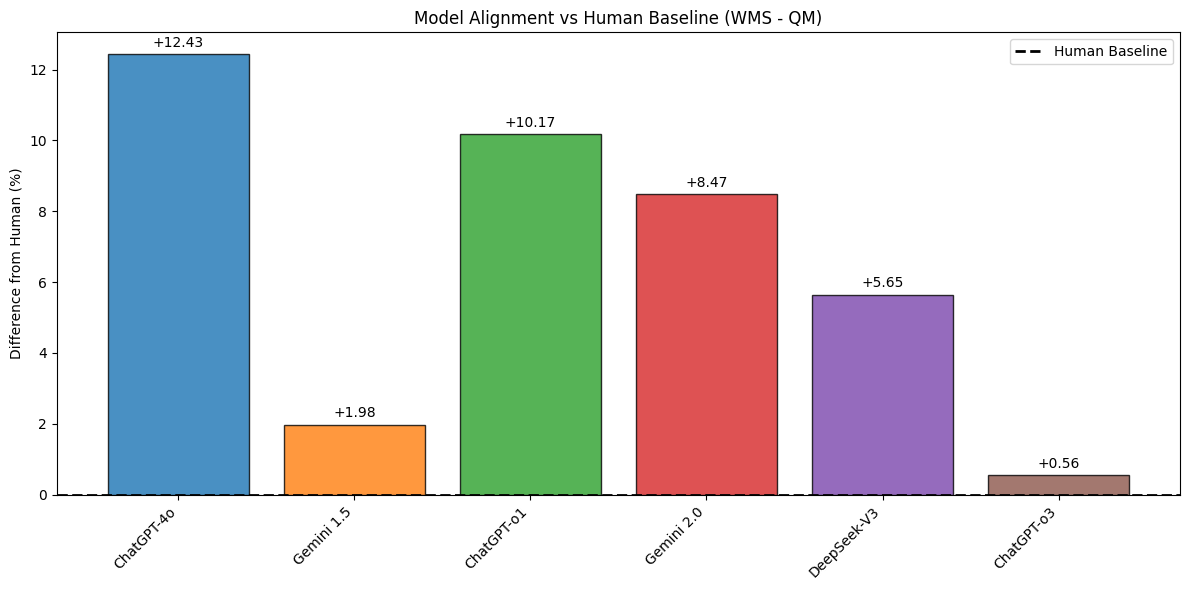

In [8]:
# Linear regression plot
for dir in ['MS', 'WMS']: # Only loop through the dirs that have human data
    for sheet in sheet_list:
        try:
            group = topic_sheet_df.get_group((dir, sheet)).dropna(subset=['Total_Mean%'])
        except KeyError:
            continue
            
        if group.empty or 'Human' not in group['Model'].values:
            continue # Skip if no human data to compare against

        # 1. Isolate the Human Baseline
        human_score = group.loc[group['Model'] == 'Human', 'Total_Mean%'].values[0]

        # 2. Calculate the Delta (Difference from Human)
        group = group.copy()
        group['Delta_from_Human'] = group['Total_Mean%'] - human_score
        
        # (Optional) Drop the Human row from the plot so it doesn't just show a 0 bar
        plot_group = group[group['Model'] != 'Human']
        
        current_models = plot_group['Model']
        deltas = plot_group['Delta_from_Human']

        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(current_models)) 
        
        # Plotting the differences
        rects1 = ax.bar(x, deltas, width=0.8, color=colors, edgecolor='black', alpha=0.8)

        # Draw a thick line at 0 (The Human Baseline)
        ax.axhline(0, color='black', linewidth=2, linestyle='--', label='Human Baseline')

        ax.set_ylabel('Difference from Human (%)')
        ax.set_title(f'Model Alignment vs Human Baseline ({dir} - {sheet})')
        ax.set_xticks(x)
        ax.set_xticklabels(current_models, rotation=45, ha='right')
        ax.legend()

        # Add labels (adds a '+' sign if the model beat the human)
        ax.bar_label(rects1, padding=3, fmt='%+.2f')

        plt.tight_layout()
        plt.show()

# Lingress

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_24746/2397760483.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = dir_df.pivot_table(



--- Alignment & IRR Statistics for Directory: MS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.2287      78.7617           0.7103     0.5046                   19.1240            27.8589           0.0566
 Gemini 1.5            0.1480      81.8527           0.2557     0.0654                   20.7691            30.2480           0.1399
 ChatGPT-o1            0.1056      88.2878           0.4634     0.2148                   19.1351            30.0001           0.0505
 Gemini 2.0            0.1902      80.1266           0.6174     0.3812                   17.8532            27.5776           0.0606
DeepSeek-V3            0.3106      62.7638           0.6924     0.4794                   13.8618            21.3976           0.0809
 ChatGPT-o3            0.6858      31.3803           0.8379     0.7022                   11.3077            15.4805           0.1117



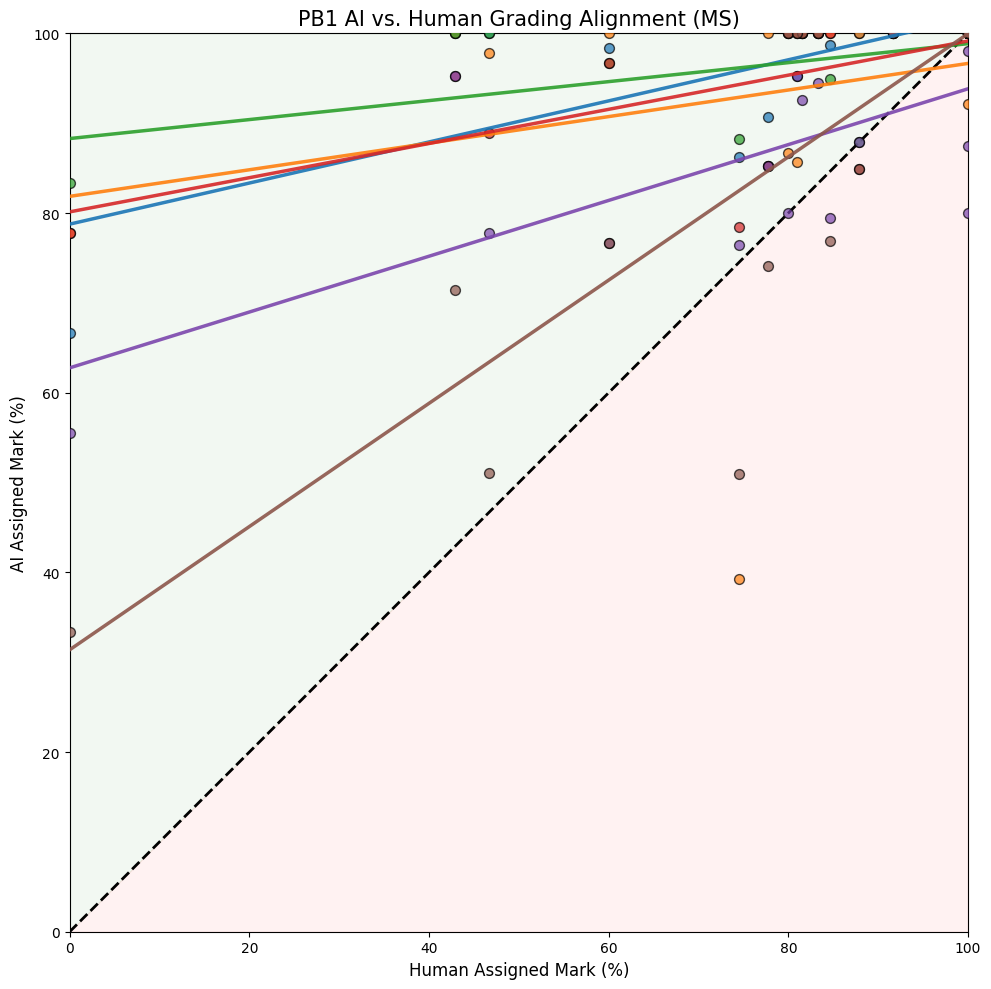

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_24746/2397760483.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = dir_df.pivot_table(



--- Alignment & IRR Statistics for Directory: WMS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.0775      92.3545           0.5927     0.3513                   21.0285            31.4583           0.0263
 Gemini 1.5            0.1769      79.2188           0.6251     0.3908                   18.3366            26.5312           0.0552
 ChatGPT-o1            0.3315      69.1395           0.7086     0.5021                   17.4539            25.6437           0.0825
 Gemini 2.0            0.2741      73.8252           0.8288     0.6869                   17.6982            25.8764           0.0463
DeepSeek-V3            0.2904      66.2500           0.7612     0.5794                   13.3460            22.0966           0.0619
 ChatGPT-o3            0.5628      43.9490           0.7608     0.5788                   13.9112            19.2536           0.1200



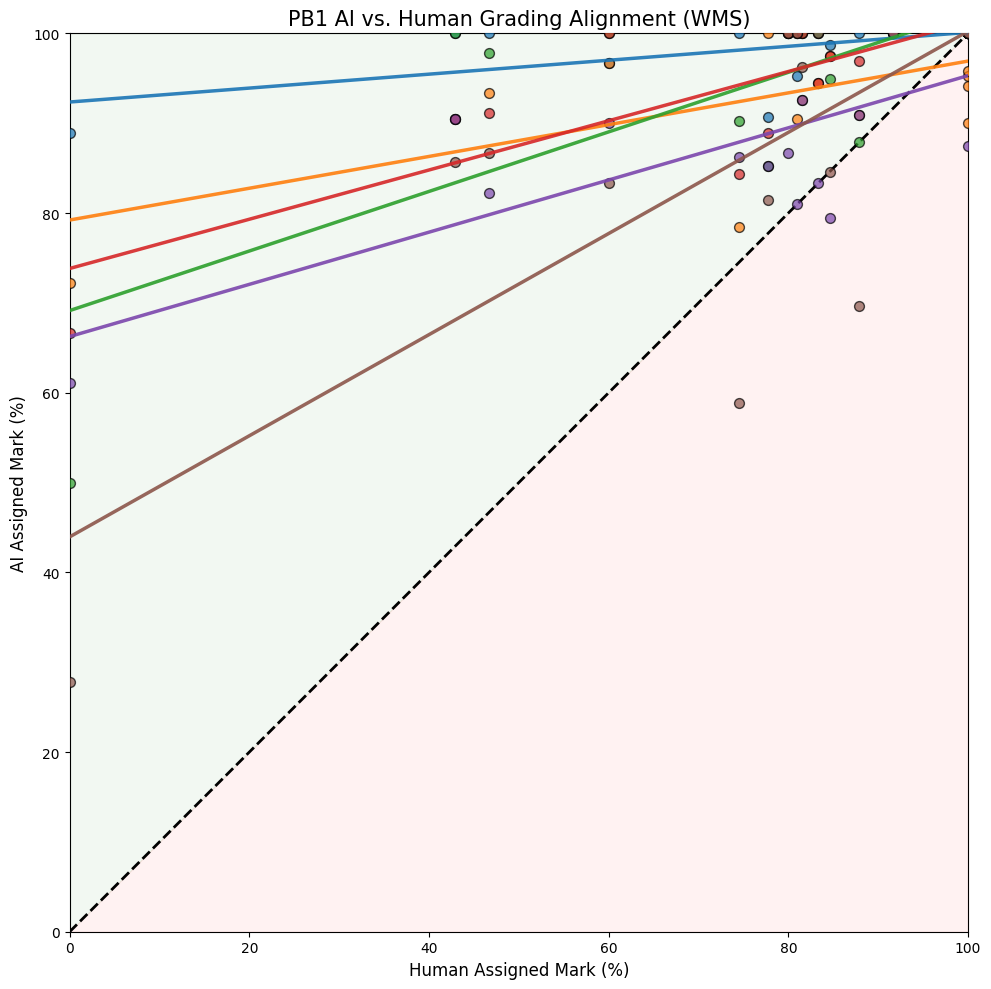

In [18]:
# Pivot table loop
for current_dir in ['MS', 'WMS']:
    # Filter the master_df for just this specific directory
    dir_df = master_df[master_df['Dir'] == current_dir]

    # Pivot the data for just this directory
    question_pivot = dir_df.pivot_table(
        index=['Sheet', 'Question Number'], 
        columns='Model', 
        values='mean percentage mark' 
    ).reset_index()

    fig, ax = plt.subplots(figsize=(12, 10))

    # Separate AI models from the Human baseline (preserves your original list order)
    ai_models = [m for m in model_list if m in question_pivot.columns and m != 'Human']
    
    # List to store our text statistics
    stats_list = []

    # Plot linear regression
    for i, model in enumerate(ai_models):
        if question_pivot[model].notna().any():
            x = question_pivot['Human'].astype(float)
            y = question_pivot[model].astype(float)
        
            # A. Calculate Linear Regression with scipy FIRST
            res = linregress(x, y)
            slope, intercept = res.slope, res.intercept
            slope_stderr = res.stderr
            pearson_r = res.rvalue        
            r_squared = pearson_r ** 2    
            
            # Calculate RMSE and MAE vs Human logic
            rmse = np.sqrt(np.mean((y - x)**2))
            mae = np.mean(np.abs(y - x))  
            
            # Save stats for the text printout 
            stats_list.append({
                'Model': model,
                'Gradient (Slope)': slope,
                'Y-Intercept': intercept,
                'Pearson r (IRR)': pearson_r,
                'R-squared': r_squared,
                'MAE (Avg Disagreement %)': mae,
                'RMSE vs Human (%)': rmse,
                'Slope Std Error': slope_stderr
            })

            # B. Draw the Scatter Points 
            label_text = f"{model} (r={pearson_r:.2f}, int={intercept:.1f}, R²={r_squared:.2f})"
            ax.scatter(x, y, label=label_text, color=colors[i], 
                       s=50, alpha=0.7, edgecolors='black', zorder=3)
            
            # C. Draw the Regression Line
            x_vals = np.array([0, 100]) 
            y_vals = slope * x_vals + intercept
            ax.plot(x_vals, y_vals, color=colors[i], linestyle='-', 
                    linewidth=2.5, alpha=0.9, zorder=4)

    # ==========================================
    # --- PRINT THE TEXT STATISTICS ---
    # ==========================================
    print(f"\n{'='*135}")
    print(f"--- Alignment & IRR Statistics for Directory: {current_dir} ---")
    print(f"{'='*135}")
    if stats_list:
        stats_df = pd.DataFrame(stats_list)
        # REMOVED SORTING: Data prints exactly in the order of model_list
        print(stats_df.to_string(index=False, float_format="%.4f"))
    else:
        print("No comparative data available.")
    print(f"{'='*135}\n")

    # ==========================================
    # --- DRAW THE SCATTER PLOT ---
    # ==========================================
    min_val, max_val = -0, 100
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='y=x', zorder=2)

    ax.set_xlabel('Human Assigned Mark (%)', fontsize=12)
    ax.set_ylabel('AI Assigned Mark (%)', fontsize=12)
    ax.set_title(f'PB1: AI vs. Human Grading Alignment ({current_dir})', fontsize=15)

    ax.fill_between([min_val, max_val], [min_val, max_val], max_val, color='green', alpha=0.05, label='AI > Human')
    ax.fill_between([min_val, max_val], min_val, [min_val, max_val], color='red', alpha=0.05, label='Human > AI')

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)

    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Save figure
    output_dir = '../Plots/AIM'
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, f'AIM_{current_dir}_Lingress'), dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# Heat Map

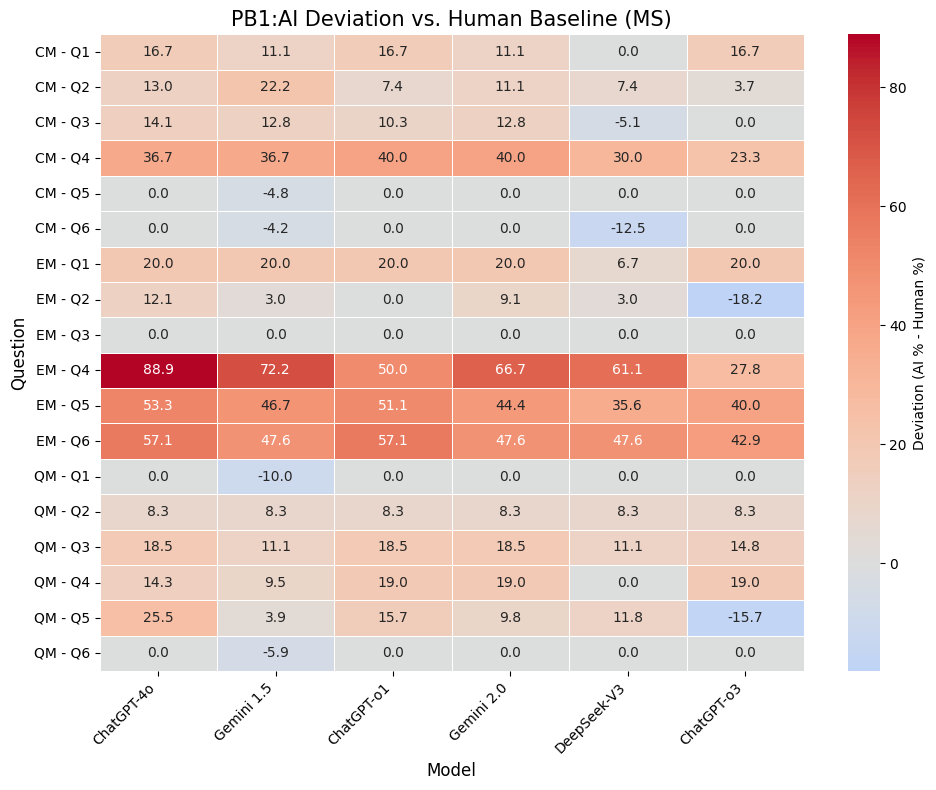

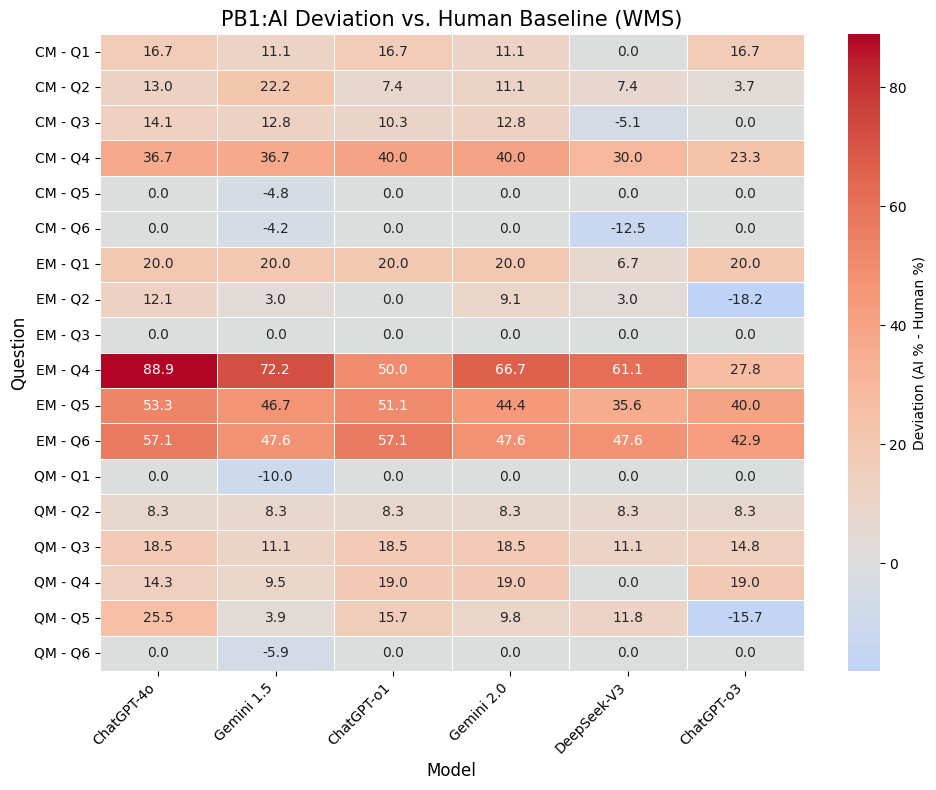

In [22]:
# Pivot table loop
for current_dir in ['MS', 'WMS']:
    # ==========================================
    # --- DRAW THE DEVIATION HEATMAP ---
    # ==========================================
    deviation_df = pd.DataFrame()
    y_labels = question_pivot['Sheet'].astype(str) + " - Q" + question_pivot['Question Number'].astype(str)
    
    for model in ai_models:
        if model in question_pivot.columns and question_pivot[model].notna().any():
            deviation_df[model] = question_pivot[model] - question_pivot['Human']
            
    if not deviation_df.empty:
        deviation_df.index = y_labels

        fig_height = max(8, len(deviation_df) * 0.4) 
        plt.figure(figsize=(10, fig_height))
        
        sns.heatmap(
            deviation_df, 
            cmap='coolwarm', 
            center=0, 
            annot=True,         
            fmt=".1f",          
            linewidths=0.5,     
            cbar_kws={'label': 'Deviation (AI % - Human %)'}
        )

        plt.title(f'PB1:AI Deviation vs. Human Baseline ({current_dir})', fontsize=15)
        plt.ylabel('Question', fontsize=12)
        plt.xlabel('Model', fontsize=12)
        plt.xticks(rotation=45, ha='right')

        # Save figure
        output_dir = '../Plots/Heat_Maps'
        os.makedirs(output_dir, exist_ok=True)
        plt.savefig(os.path.join(output_dir, f'AIM_{current_dir}_Heat_Map'), dpi=300, bbox_inches='tight')
        
        plt.tight_layout()
        plt.show()

# Topic Linegress

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_89668/329006816.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: MS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.0890      90.4615           0.3698     0.1368                   13.6776            18.7712           0.1118
 Gemini 1.5            0.0000     100.0000           0.0000     0.0000                   15.7123            20.8498           0.0000
 ChatGPT-o1            0.1559      82.9789           0.4055     0.1645                   11.8329            17.2351           0.1757
 Gemini 2.0            0.1574      83.7079           0.3987     0.1589                   12.6876            17.8595           0.1810
DeepSeek-V3            0.4129      52.4129           0.7011     0.4915                    8.8022            10.3171           0.2100
 ChatGPT-o3            0.6459      33.5045           0.7322     0.5361                    7.4549            10.2343           0.3004



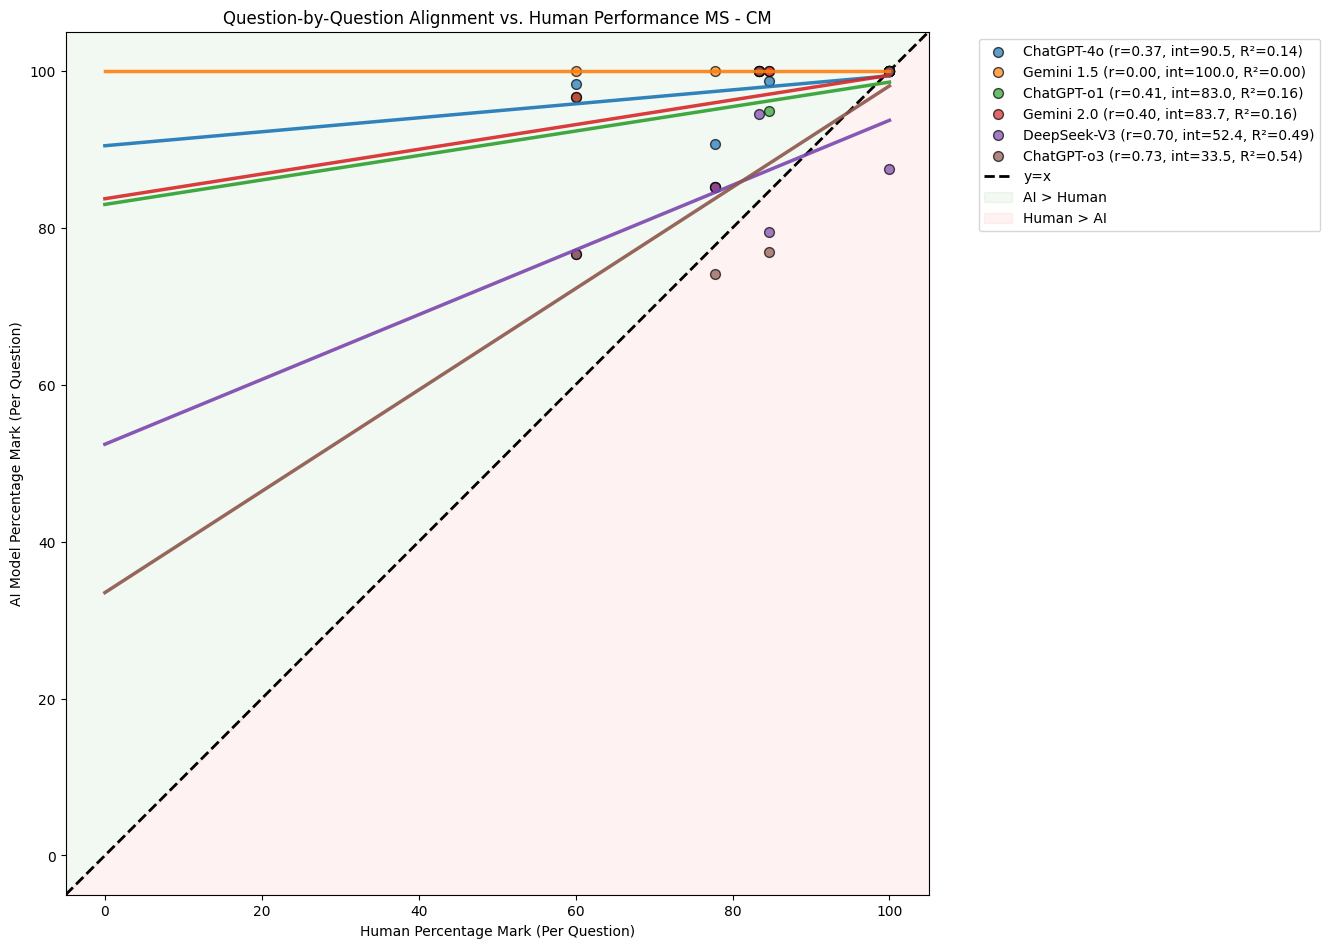


--- Alignment & IRR Statistics for Directory: MS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.2900      77.1724           0.7885     0.6218                   34.8773            43.0138           0.1131
 Gemini 1.5            0.1577      84.3095           0.6231     0.3882                   34.1366            44.9414           0.0990
 ChatGPT-o1            0.0949      89.5512           0.4637     0.2150                   35.6349            47.3536           0.0906
 Gemini 2.0            0.1632      81.4033           0.6779     0.4595                   32.5685            42.7883           0.0885
DeepSeek-V3            0.3303      63.0664           0.7726     0.5969                   23.1746            33.6603           0.1357
 ChatGPT-o3            0.6791      33.0018           0.9299     0.8647                   14.8966            19.8174           0.1343



/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_89668/329006816.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(


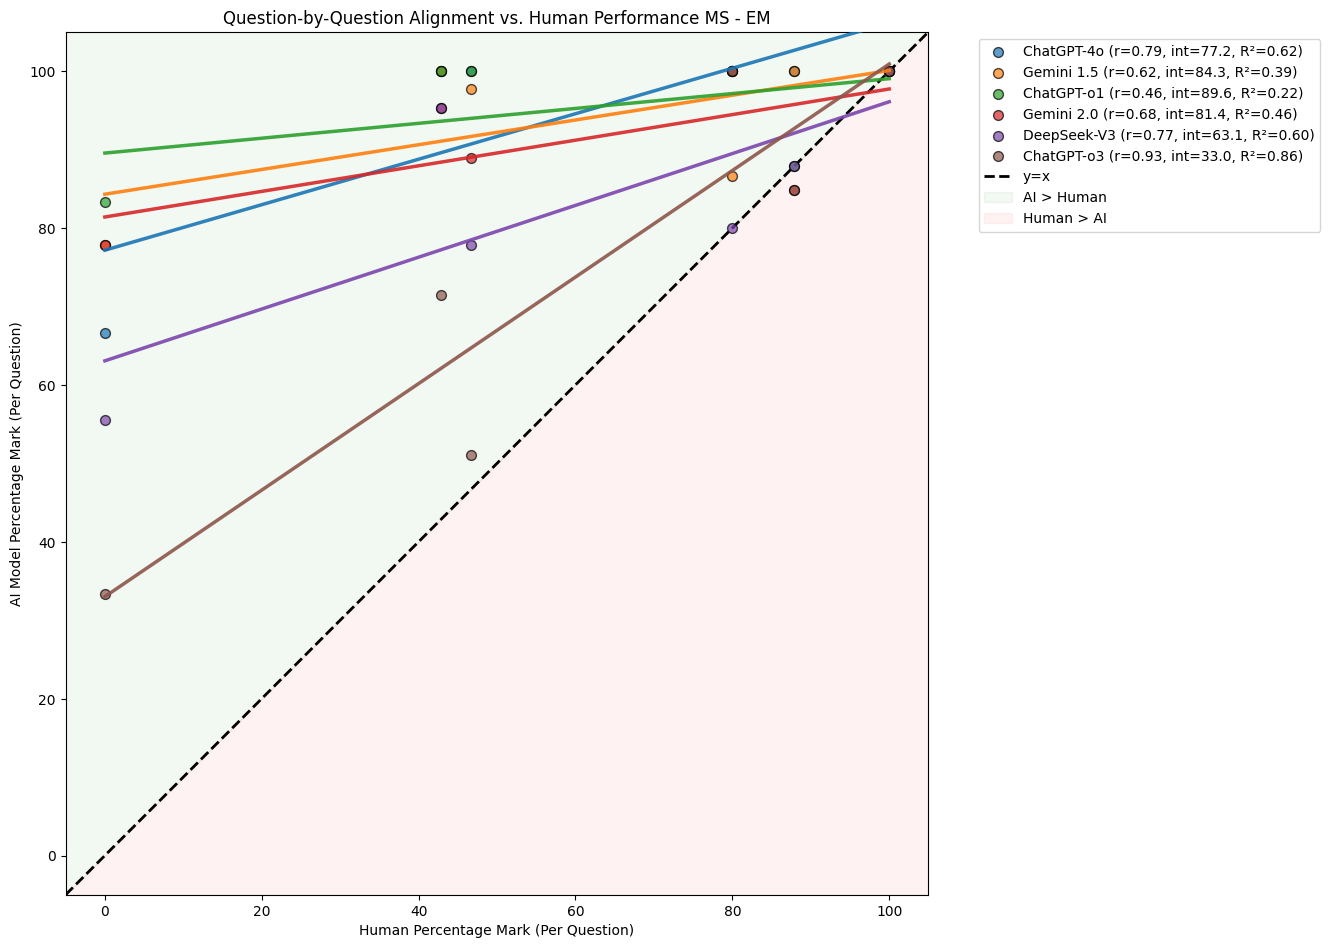

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_89668/329006816.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: MS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.3833      63.1493           0.7407     0.5487                    8.8170            11.2166           0.1738
 Gemini 1.5            1.4508     -41.6389           0.6561     0.4304                   12.4585            17.0404           0.8345
 ChatGPT-o1            0.2778      73.5610           0.6206     0.3852                    9.9375            12.6727           0.1755
 Gemini 2.0            0.5094      51.5285           0.6206     0.3852                    8.3035            11.4788           0.3218
DeepSeek-V3            0.2460      68.7143           0.2691     0.0724                    9.6086            11.5807           0.4402
 ChatGPT-o3            1.1577     -10.1625           0.6206     0.3852                   11.5715            14.8819           0.7313



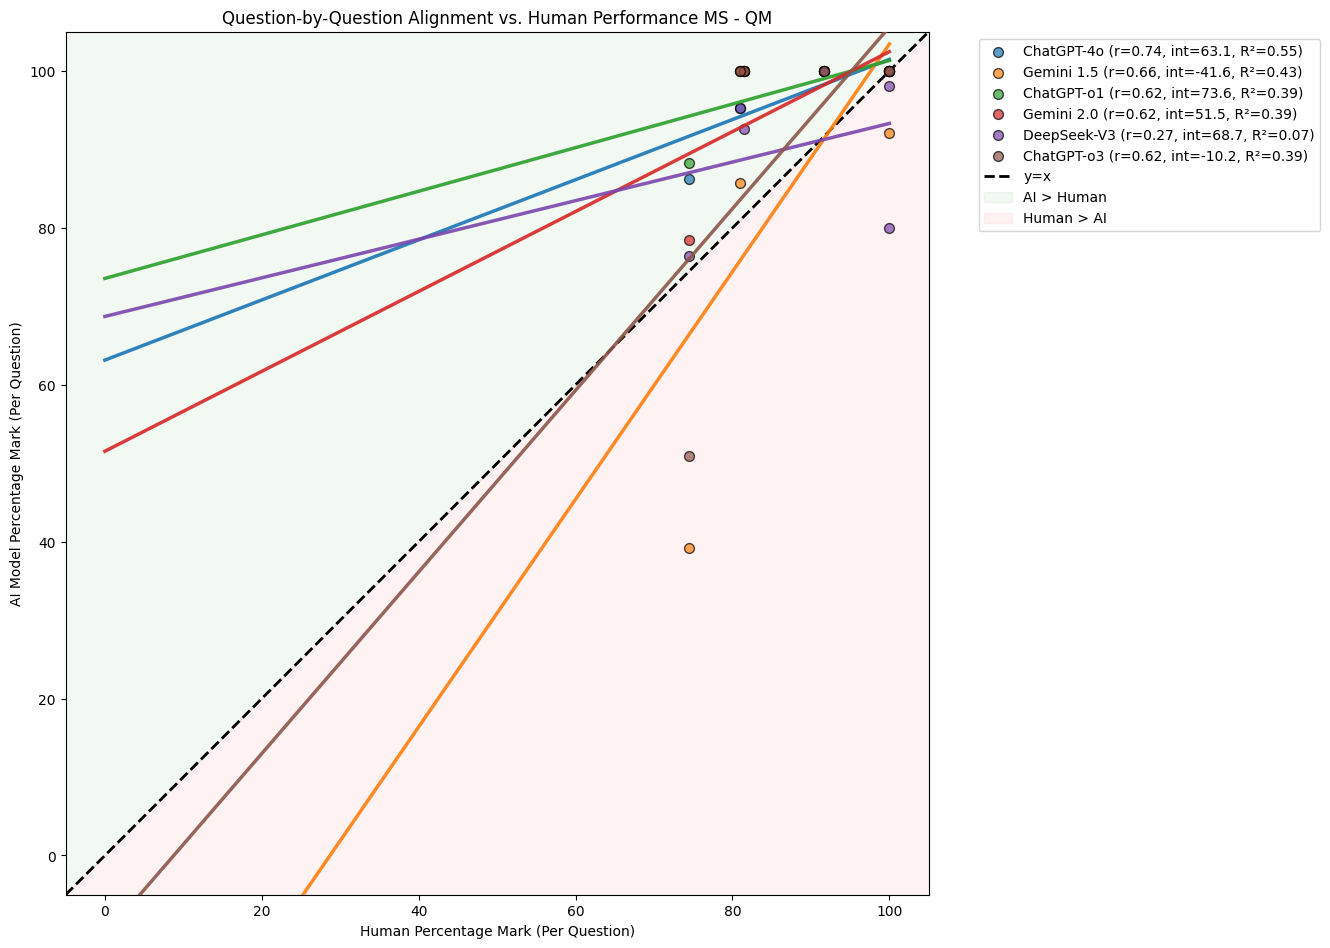

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_89668/329006816.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: WMS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.1249      87.1564           0.5147     0.2650                   13.3998            18.2078           0.1041
 Gemini 1.5           -0.0487     100.7064          -0.3715     0.1380                   15.2915            19.0006           0.0608
 ChatGPT-o1            0.0841      89.5891           0.2107     0.0444                   12.3884            18.4293           0.1951
 Gemini 2.0            0.0681      91.0516           0.2296     0.0527                   12.5071            18.3088           0.1444
DeepSeek-V3            0.1350      76.2089           0.2869     0.0823                    9.1726            13.7684           0.2253
 ChatGPT-o3            0.4617      52.6594           0.7464     0.5571                    7.2840            11.8035           0.2058



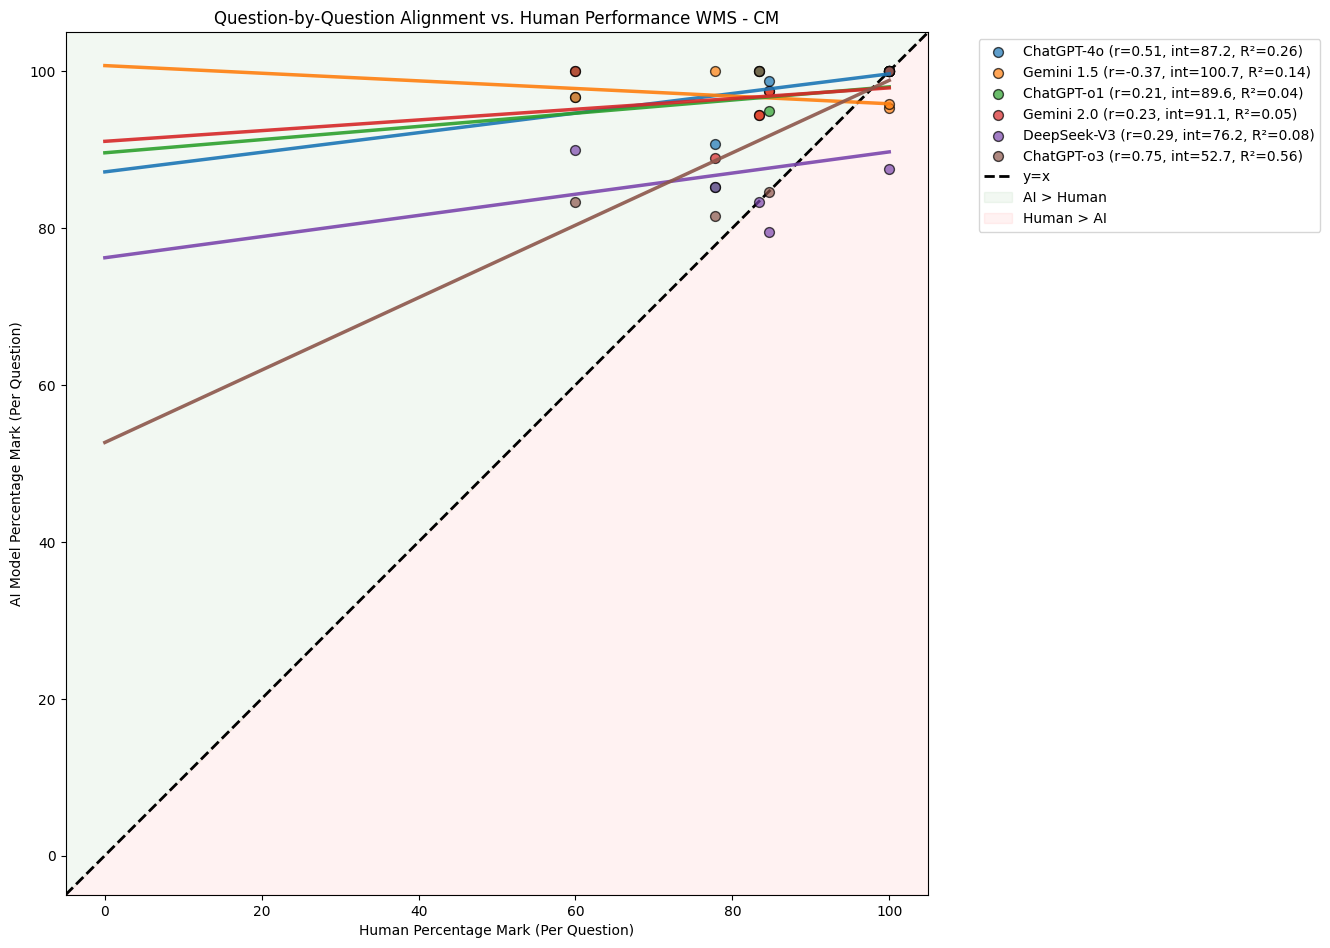

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_89668/329006816.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: WMS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.0967      92.3908           0.7885     0.6218                   38.5810            49.2577           0.0377
 Gemini 1.5            0.2398      76.8699           0.8702     0.7573                   31.5897            40.9687           0.0679
 ChatGPT-o1            0.3890      66.1039           0.7268     0.5282                   29.7090            38.2484           0.1838
 Gemini 2.0            0.3174      71.9630           0.9346     0.8734                   31.3035            39.0938           0.0604
DeepSeek-V3            0.3176      66.3096           0.8908     0.7935                   25.6638            34.9284           0.0810
 ChatGPT-o3            0.5629      44.7767           0.7665     0.5876                   24.8028            28.6906           0.2358



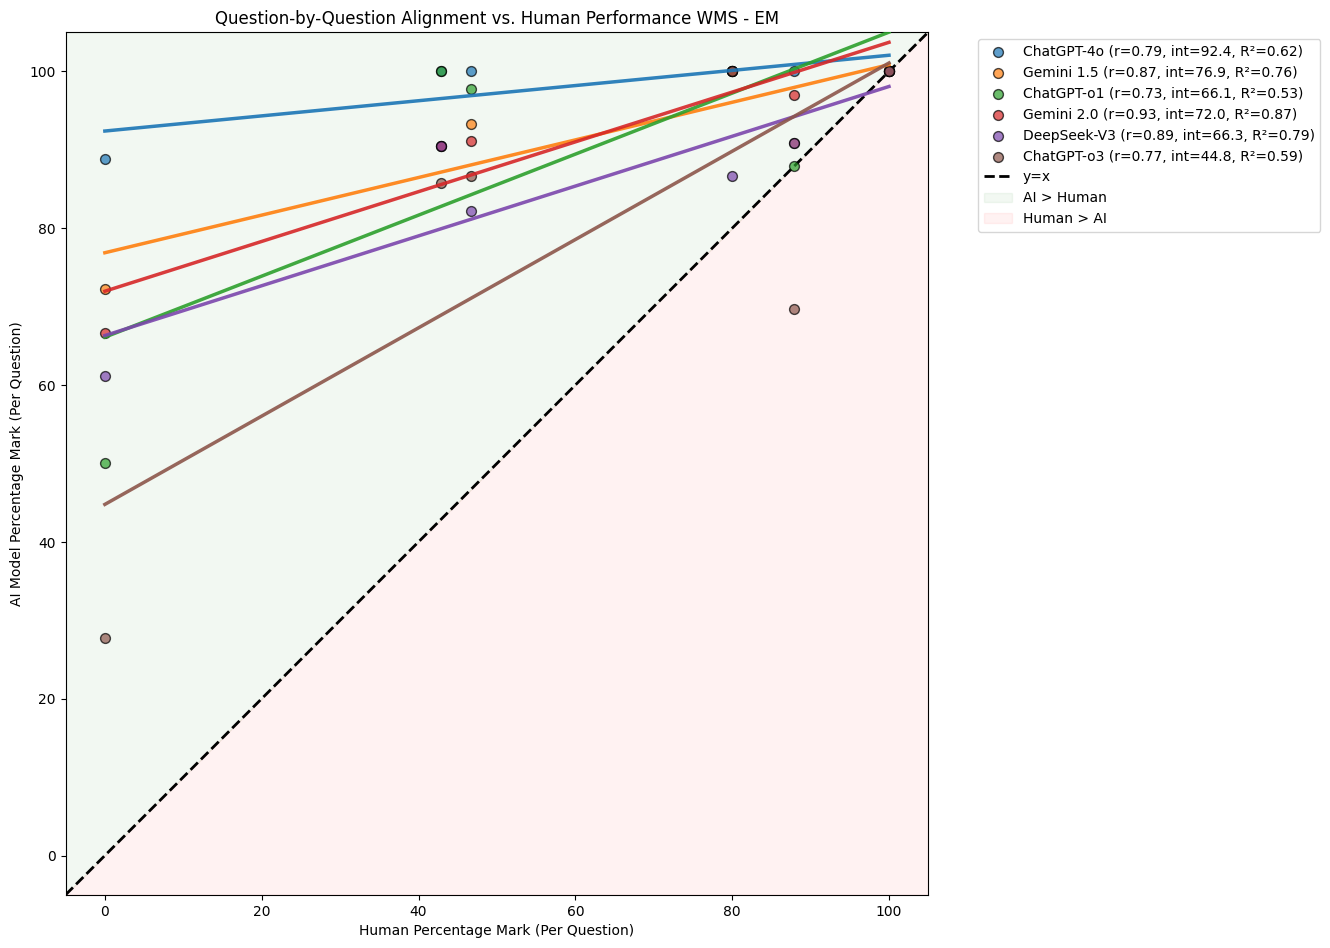

/var/folders/17/723pj1316pl5m9z25hgjlqbc0000gn/T/ipykernel_89668/329006816.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  question_pivot = topic_df.pivot_table(



--- Alignment & IRR Statistics for Directory: WMS ---
      Model  Gradient (Slope)  Y-Intercept  Pearson r (IRR)  R-squared  MAE (Avg Disagreement %)  RMSE vs Human (%)  Slope Std Error
 ChatGPT-4o            0.0592      93.9948           0.3265     0.1066                   11.1046            14.5271           0.0856
 Gemini 1.5            0.3845      57.0576           0.5806     0.3371                    8.1287             8.5008           0.2696
 ChatGPT-o1            0.2315      77.9675           0.6206     0.3852                   10.2643            13.0464           0.1463
 Gemini 2.0            0.3705      64.7480           0.6206     0.3852                    9.2839            12.0506           0.2340
DeepSeek-V3            0.6460      36.3924           0.8442     0.7126                    5.2015             7.4309           0.2051
 ChatGPT-o3            1.0150       3.0928           0.6571     0.4317                    9.6470            12.2324           0.5823



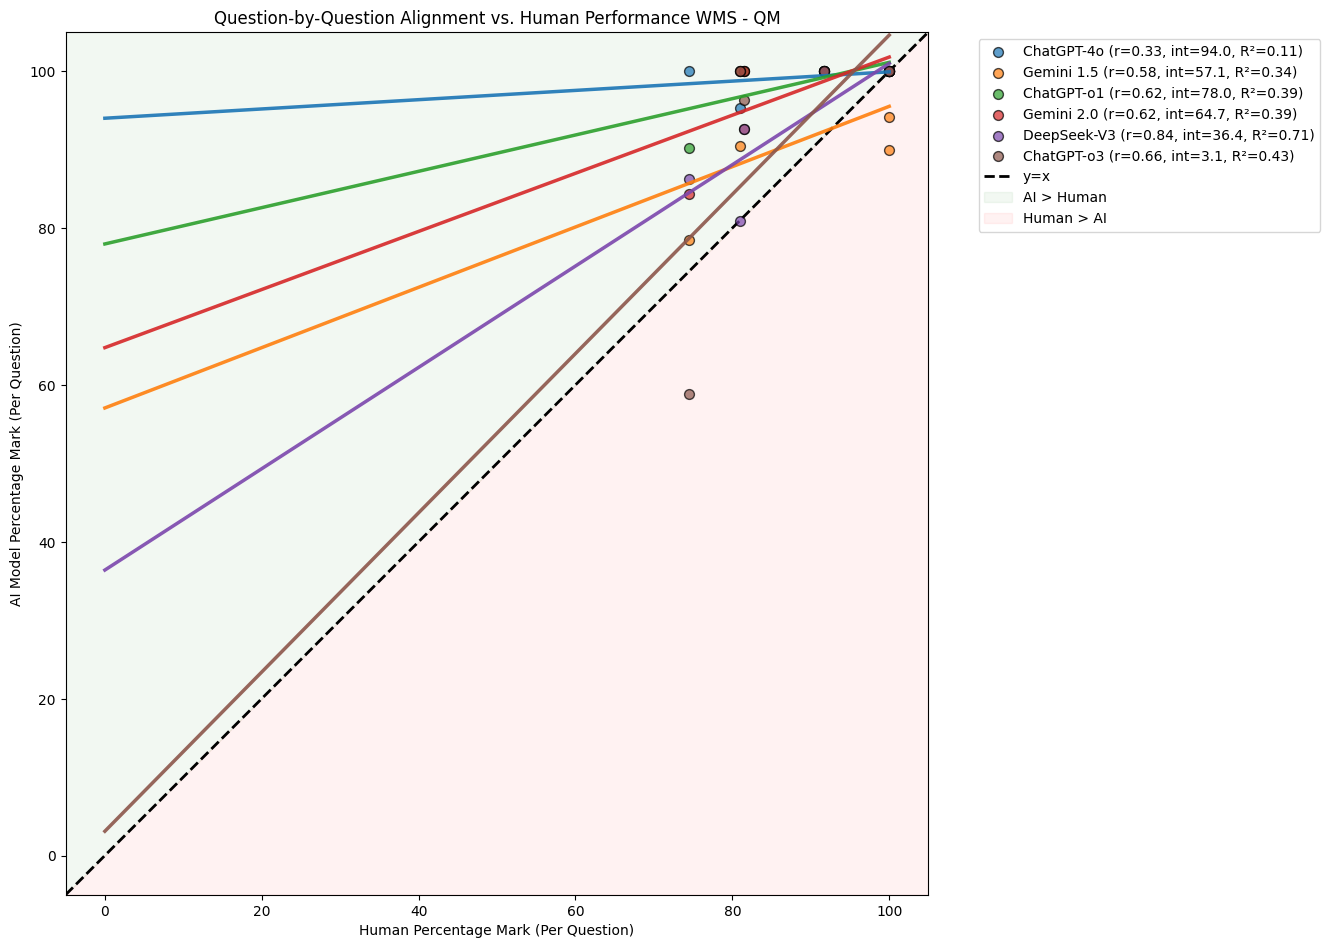

In [73]:
# Pivot table loop
for current_dir in ['MS', 'WMS']:
    for sheet in sheet_list:
        # Filter the master_df for just this specific directory
        dir_df = master_df[master_df['Dir'] == current_dir]
        topic_df = dir_df[dir_df['Sheet'] == sheet]

        # Pivot the data for just this directory
        question_pivot = topic_df.pivot_table(
            index=['Sheet', 'Question Number'], 
            columns='Model', 
            values='mean percentage mark' 
        ).reset_index()

        fig, ax = plt.subplots(figsize=(12, 10))

        # Separate AI models from the Human baseline (preserves your original list order)
        ai_models = [m for m in model_list if m in question_pivot.columns and m != 'Human']
        
        # List to store our text statistics
        stats_list = []

        # Plot linear regression
        for i, model in enumerate(ai_models):
            if question_pivot[model].notna().any():
                x = question_pivot['Human'].astype(float)
                y = question_pivot[model].astype(float)
            
                # A. Calculate Linear Regression with scipy FIRST
                res = linregress(x, y)
                slope, intercept = res.slope, res.intercept
                slope_stderr = res.stderr
                pearson_r = res.rvalue        
                r_squared = pearson_r ** 2    
                
                # Calculate RMSE and MAE vs Human logic
                rmse = np.sqrt(np.mean((y - x)**2))
                mae = np.mean(np.abs(y - x))  
                
                # Save stats for the text printout 
                stats_list.append({
                    'Model': model,
                    'Gradient (Slope)': slope,
                    'Y-Intercept': intercept,
                    'Pearson r (IRR)': pearson_r,
                    'R-squared': r_squared,
                    'MAE (Avg Disagreement %)': mae,
                    'RMSE vs Human (%)': rmse,
                    'Slope Std Error': slope_stderr
                })

                # B. Draw the Scatter Points 
                label_text = f"{model} (r={pearson_r:.2f}, int={intercept:.1f}, R²={r_squared:.2f})"
                ax.scatter(x, y, label=label_text, color=colors[i], 
                        s=50, alpha=0.7, edgecolors='black', zorder=3)
                
                # C. Draw the Regression Line
                x_vals = np.array([0, 100]) 
                y_vals = slope * x_vals + intercept
                ax.plot(x_vals, y_vals, color=colors[i], linestyle='-', 
                        linewidth=2.5, alpha=0.9, zorder=4)

        # ==========================================
        # --- PRINT THE TEXT STATISTICS ---
        # ==========================================
        print(f"\n{'='*90}")
        print(f"--- Alignment & IRR Statistics for Directory: {current_dir} ---")
        print(f"{'='*90}")
        if stats_list:
            stats_df = pd.DataFrame(stats_list)
            # REMOVED SORTING: Data prints exactly in the order of model_list
            print(stats_df.to_string(index=False, float_format="%.4f"))
        else:
            print("No comparative data available.")
        print(f"{'='*90}\n")

        # ==========================================
        # --- DRAW THE SCATTER PLOT ---
        # ==========================================
        min_val, max_val = -5, 105
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='y=x', zorder=2)

        ax.set_xlabel('Human Percentage Mark (Per Question)')
        ax.set_ylabel('AI Model Percentage Mark (Per Question)')
        ax.set_title(f'Question-by-Question Alignment vs. Human Performance {current_dir} - {sheet}')

        ax.fill_between([min_val, max_val], [min_val, max_val], max_val, color='green', alpha=0.05, label='AI > Human')
        ax.fill_between([min_val, max_val], min_val, [min_val, max_val], color='red', alpha=0.05, label='Human > AI')

        ax.set_aspect('equal', adjustable='box')
        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()   